# Scalability Analysis

Plots and per-model timing metrics from `scalability_results1.csv` (the complete 8-model run).

**Produces:**
1. `cum_train_evolution.{png,pdf}` &mdash; cumulative training time vs `n`, one line per model
2. `cum_infer_evolution.{png,pdf}` &mdash; cumulative inference time vs `n`, one line per model
3. `mean_build_time.{png,pdf}` + `build_time_summary.csv` &mdash; average per-product graph build time per model
4. **Epochs analysis** &mdash; mean epochs to train one product, and average time per epoch, per model

> The epochs analysis needs `epochs_trained` / `s_per_epoch` columns. `results1.csv` does not
> carry them yet, so the relevant cell falls back to `results.csv` (which does) and prints a
> notice. Once you log epochs into `results1.csv`, the fallback simply stops triggering.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# Resolve the folder this notebook lives in (works as .ipynb or via __file__).
try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    HERE = os.getcwd()

CSV = os.path.join(HERE, "scalability_results1.csv")
df = pd.read_csv(CSV)
print(f"Loaded {len(df)} rows from {os.path.basename(CSV)}")
print("Columns:", list(df.columns))
df.head()

Loaded 4000 rows from scalability_results1.csv
Columns: ['variant', 'product_id', 'store_id', 'n', 'build_s', 'train_s', 'infer_s', 'cum_build_s', 'cum_train_s', 'cum_infer_s', 'product_peak_gpu_mb', 'product_peak_ram_mb', 'cum_peak_gpu_mb', 'cum_peak_ram_mb']


,variant,product_id,store_id,n,build_s,train_s,infer_s,cum_build_s,cum_train_s,cum_infer_s,product_peak_gpu_mb,product_peak_ram_mb,cum_peak_gpu_mb,cum_peak_ram_mb
0,lstm_baseline,27,6269,1,0.0,11.804,0.064,0.0,11.804,0.064,0.0,23.50,0.0,23.5
1,lstm_baseline,55,6269,2,0.0,5.269,0.064,0.0,17.073,0.128,0.0,0.00,0.0,23.5
2,lstm_baseline,71,6269,3,0.0,8.132,0.063,0.0,25.205,0.191,0.0,0.11,0.0,23.5
3,lstm_baseline,116,6269,4,0.0,5.066,0.069,0.0,30.271,0.260,0.0,0.33,0.0,23.5
4,lstm_baseline,128,6269,5,0.0,6.118,0.063,0.0,36.389,0.323,0.0,0.69,0.0,23.5


In [2]:
# Stable, readable ordering: baselines first, then graph2vec, gcn, gat.
ORDER = ["lstm_baseline", "mlp_baseline",
         "graph2vec_lstm", "graph2vec_mlp",
         "gcn_lstm", "gcn_mlp",
         "gat_lstm", "gat_mlp"]
variants = [v for v in ORDER if v in df["variant"].unique()]
variants += [v for v in df["variant"].unique() if v not in variants]  # any extras

cmap   = plt.get_cmap("tab10")
colors = {v: cmap(i % 10) for i, v in enumerate(variants)}
variants

['lstm_baseline',
 'mlp_baseline',
 'graph2vec_lstm',
 'graph2vec_mlp',
 'gcn_lstm',
 'gcn_mlp',
 'gat_lstm',
 'gat_mlp']

In [3]:
def line_plot(ycol, ylabel, title, outname):
    """One line per model; saves png+pdf into HERE and shows inline."""
    fig, ax = plt.subplots(figsize=(11, 6))
    for v in variants:
        sub = df[df["variant"] == v].sort_values("n")
        ax.plot(sub["n"], sub[ycol], label=v, color=colors[v], linewidth=1.6)
    ax.set_xlabel("Number of products processed (n)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, ncol=2)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        path = os.path.join(HERE, f"{outname}.{ext}")
        fig.savefig(path, dpi=150, bbox_inches="tight")
        print(f"Saved {path}")
    plt.show()

## 1. Cumulative training time evolution

Saved C:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\DynamicSimilarities\Scalability Analysis\cum_train_evolution.png
Saved C:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\DynamicSimilarities\Scalability Analysis\cum_train_evolution.pdf


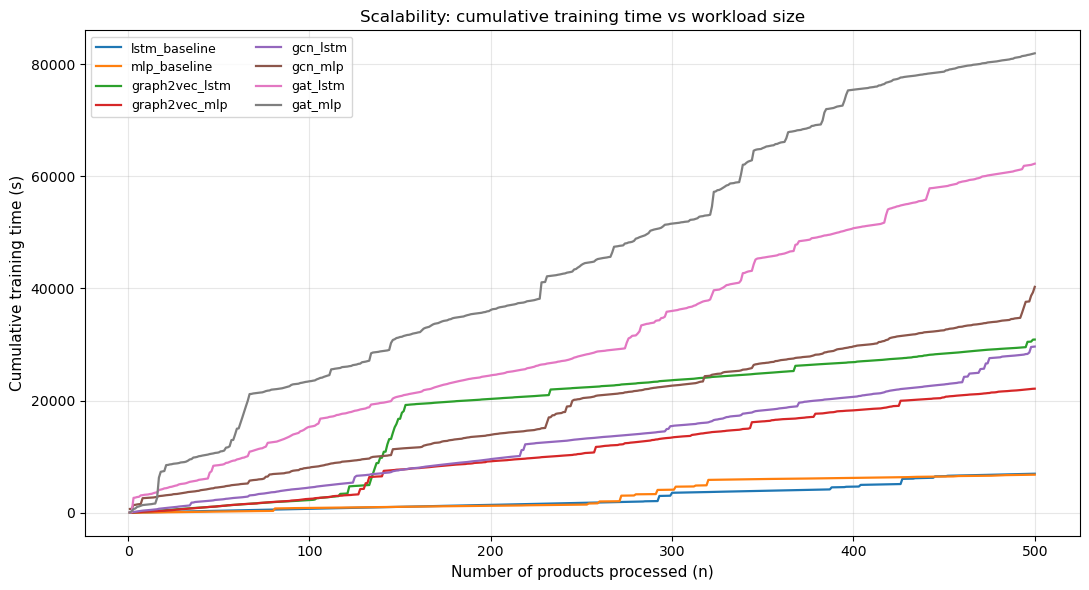

In [4]:
line_plot(
    "cum_train_s",
    "Cumulative training time (s)",
    "Scalability: cumulative training time vs workload size",
    "cum_train_evolution",
)

## 2. Cumulative inference time evolution

Saved C:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\DynamicSimilarities\Scalability Analysis\cum_infer_evolution.png
Saved C:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\DynamicSimilarities\Scalability Analysis\cum_infer_evolution.pdf


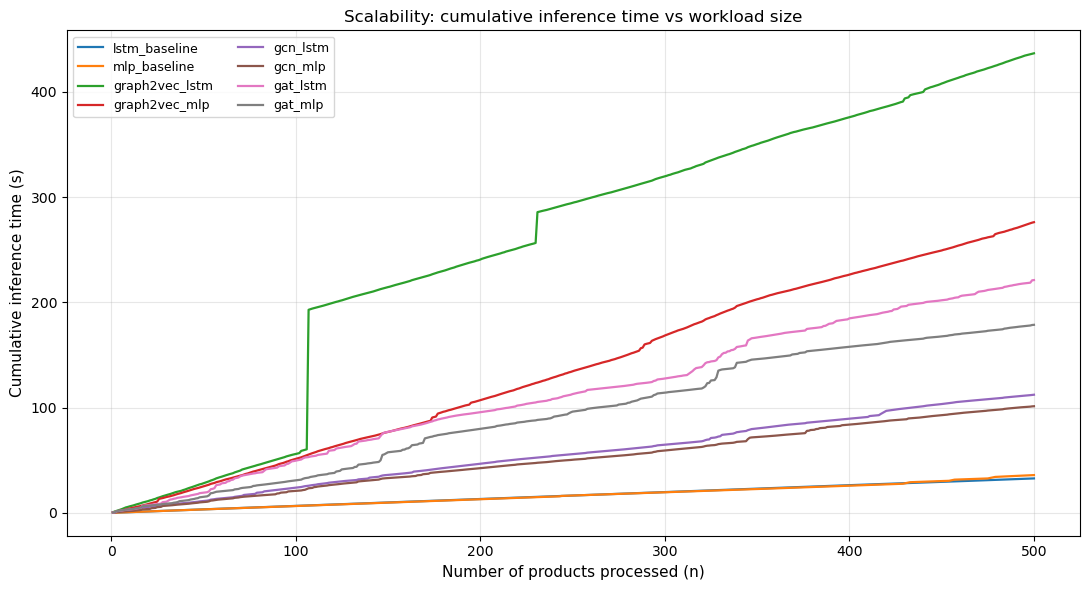

In [5]:
line_plot(
    "cum_infer_s",
    "Cumulative inference time (s)",
    "Scalability: cumulative inference time vs workload size",
    "cum_infer_evolution",
)

## 3. Average graph build time per model

Saved C:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\DynamicSimilarities\Scalability Analysis\build_time_summary.csv



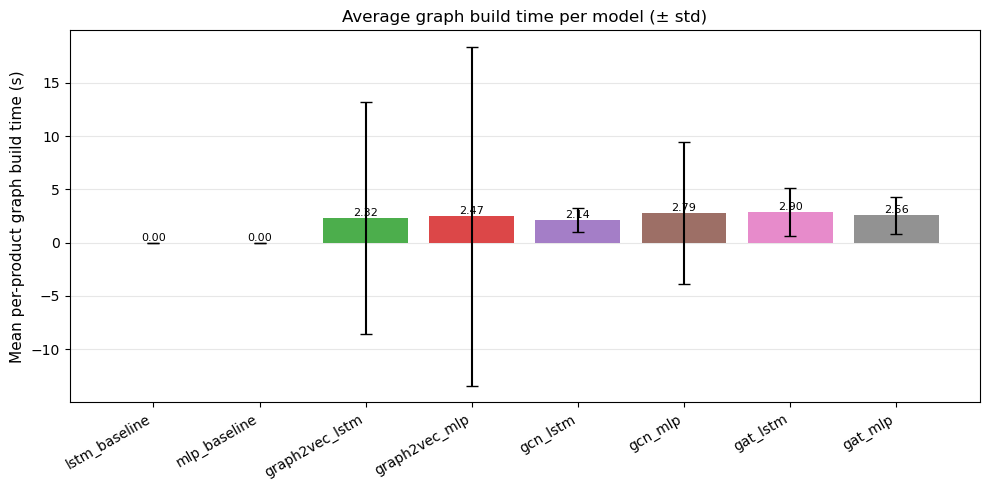

,variant,mean_build_s,std_build_s,total_build_s,n_products
0,lstm_baseline,0.0000,0.0000,0.000,500
1,mlp_baseline,0.0000,0.0000,0.000,500
2,graph2vec_lstm,2.3187,10.8493,1159.358,500
3,graph2vec_mlp,2.4688,15.8780,1234.407,500
4,gcn_lstm,2.1367,1.1610,1068.340,500
5,gcn_mlp,2.7941,6.6550,1397.055,500
6,gat_lstm,2.9020,2.2418,1450.981,500
7,gat_mlp,2.5627,1.7106,1281.371,500


In [6]:
build = (df.groupby("variant")["build_s"]
           .agg(mean_build_s="mean", std_build_s="std",
                total_build_s="sum", n_products="count")
           .reindex(variants)
           .reset_index())
build_csv = os.path.join(HERE, "build_time_summary.csv")
build.round(4).to_csv(build_csv, index=False)
print(f"Saved {build_csv}\n")

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(build["variant"], build["mean_build_s"],
              yerr=build["std_build_s"].fillna(0), capsize=4,
              color=[colors[v] for v in build["variant"]], alpha=0.85)
ax.set_ylabel("Mean per-product graph build time (s)", fontsize=11)
ax.set_title("Average graph build time per model (± std)", fontsize=12)
ax.grid(True, axis="y", alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
for b, v in zip(bars, build["mean_build_s"]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
            f"{v:.2f}", ha="center", va="bottom", fontsize=8)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(os.path.join(HERE, f"mean_build_time.{ext}"), dpi=150, bbox_inches="tight")
plt.show()
build.round(4)

## 4. Epochs analysis &mdash; mean epochs per product & average time per epoch

Two quantities, per model:
- **mean epochs/product** = `mean(epochs_trained)` over the products of that variant.
- **avg time per epoch**, reported two ways:
  - *aggregate (weighted)* = `sum(train_s) / sum(epochs_trained)` &mdash; robust, weights long-training products more.
  - *per-product mean* = `mean(s_per_epoch)` &mdash; the unweighted average of each product's own rate.

If `results1.csv` lacks the epoch columns, we fall back to `results.csv` (which logs them) so the
numbers are real; the printed source tells you which file was used.

In [7]:
EPOCH_COLS = {"epochs_trained", "s_per_epoch"}

if EPOCH_COLS.issubset(df.columns):
    epoch_df = df
    epoch_src = os.path.basename(CSV)
else:
    # results1.csv has no epoch measurements yet -> use results.csv, which does.
    # Delete this fallback (and just use `df`) once epochs are logged in results1.csv.
    _fallback = os.path.join(HERE, "scalability_results.csv")
    epoch_df = pd.read_csv(_fallback)
    epoch_src = os.path.basename(_fallback) + "  (FALLBACK: results1.csv has no epoch columns)"

print(f"Epochs analysis source: {epoch_src}")

# A product is one training run; build_s == 0 rows are still valid training rows.
epochs = (epoch_df.groupby("variant")
            .apply(lambda g: pd.Series({
                "mean_epochs_per_product": g["epochs_trained"].mean(),
                "std_epochs_per_product":  g["epochs_trained"].std(),
                "avg_s_per_epoch_weighted": g["train_s"].sum() / max(g["epochs_trained"].sum(), 1),
                "avg_s_per_epoch_mean":     g["s_per_epoch"].mean(),
                "n_products":               len(g),
            }))
            .reindex([v for v in variants if v in epoch_df["variant"].unique()])
            .reset_index())

epochs_csv = os.path.join(HERE, "epochs_summary.csv")
epochs.round(4).to_csv(epochs_csv, index=False)
print(f"Saved {epochs_csv}\n")
epochs.round(3)

Epochs analysis source: scalability_results.csv  (FALLBACK: results1.csv has no epoch columns)
Saved C:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\DynamicSimilarities\Scalability Analysis\epochs_summary.csv



,variant,mean_epochs_per_product,std_epochs_per_product,avg_s_per_epoch_weighted,avg_s_per_epoch_mean,n_products
0,lstm_baseline,146.086,58.197,0.042,0.042,500.0
1,mlp_baseline,154.846,91.614,0.039,0.039,500.0
2,graph2vec_lstm,137.084,37.508,0.284,0.284,500.0
3,graph2vec_mlp,197.320,135.002,0.288,0.288,500.0
4,gcn_lstm,125.143,22.072,1.052,1.050,84.0


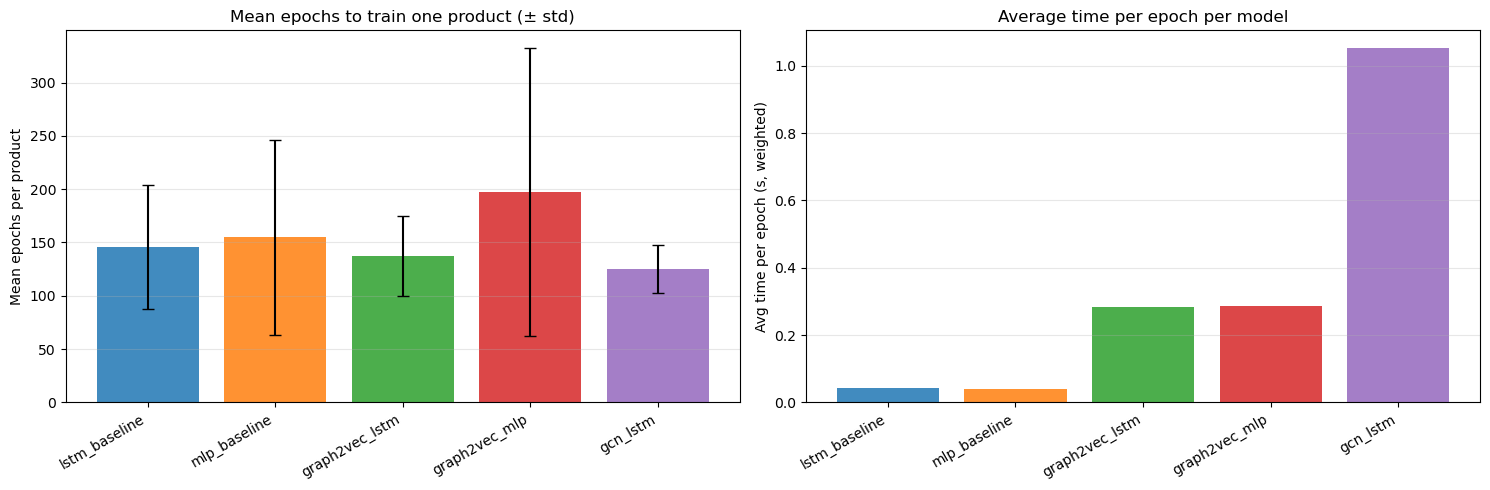

In [8]:
# Visualise the two epoch metrics side by side.
ev = [v for v in variants if v in epochs["variant"].values]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(epochs["variant"], epochs["mean_epochs_per_product"],
            yerr=epochs["std_epochs_per_product"].fillna(0), capsize=4,
            color=[colors[v] for v in epochs["variant"]], alpha=0.85)
axes[0].set_ylabel("Mean epochs per product")
axes[0].set_title("Mean epochs to train one product (± std)")
axes[0].grid(True, axis="y", alpha=0.3)
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")

axes[1].bar(epochs["variant"], epochs["avg_s_per_epoch_weighted"],
            color=[colors[v] for v in epochs["variant"]], alpha=0.85)
axes[1].set_ylabel("Avg time per epoch (s, weighted)")
axes[1].set_title("Average time per epoch per model")
axes[1].grid(True, axis="y", alpha=0.3)
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")

fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(os.path.join(HERE, f"epochs_analysis.{ext}"), dpi=150, bbox_inches="tight")
plt.show()